In [1]:
# Notebook to generate high quality plots
# we calculate and show results of varying degrees of noise and 
# their effect on the performance of the model. Noise is generated as 
# monte carlo simulation of gaussian white noise.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.chdir('./an_ml_exercise')

In [3]:
# which_plot = ''
# which_plot = '_training'
save_plot = True

# target_ = 'Qs_tavg'     #   Tveg_tavg  Qs_tavg  SoilMoist_S_tavg
# dir_ = '82.875_27.625'  # Ganga basin

# train_start_date = '2000-01-01' 
# train_end_date = '2003-12-31'
# test_start_date = '2004-01-01'
# test_end_date = '2005-12-31'

# target_ = 'Tveg_tavg'
# dir_ = '148.125_-29.125'      # Murray basin

# train_start_date = '2007-01-01' 
# train_end_date = '2012-12-31'
# test_start_date = '2005-01-01'
# test_end_date = '2006-12-31'

target_ = 'SoilMoist_S_tavg'     #   Tveg_tavg  Qs_tavg  SoilMoist_S_tavg
dir_ = '82.875_27.625'  # Ganga basin

train_start_date = '2000-01-01' 
train_end_date = '2003-12-31'
test_start_date = '2004-01-01'
test_end_date = '2005-12-31'

'2005-12-31'

In [4]:
# pcc_mcc_df = pd.read_csv('data/temporary/PCC-MC-results_{target_}_{dir_}.txt', index_col=None)
pcc_df = pd.read_csv(f'data/temporary/PCC-MC-results_{target_}_{dir_}.txt', index_col=None)
pcc_df_train = pd.read_csv(f'data/temporary/PCC-MC-results_{target_}_{dir_}_training.txt', index_col=None)
pcc_df, pcc_df_train

(    method  noise_level  r2_score      rmse       mae       nse   nse_mod  \
 0      PCC          0.0  0.972060  0.188959  0.144421  0.959286  0.820770   
 1      PCC          0.0  0.985746  0.144522  0.115985  0.976183  0.856059   
 2      PCC          0.0  0.981877  0.141417  0.107850  0.977196  0.866156   
 3      PCC          0.0  0.985253  0.145755  0.115554  0.975775  0.856594   
 4      PCC          0.0  0.985134  0.119146  0.094205  0.983813  0.883089   
 ..     ...          ...       ...       ...       ...       ...       ...   
 245    PCC          1.0  0.337980  1.153503  0.927085  0.217150  0.109533   
 246    PCC          1.0  0.334373  1.167379  0.932411  0.187596  0.111753   
 247    PCC          1.0  0.322878  1.188707  0.959443  0.262914  0.134372   
 248    PCC          1.0  0.383430  1.098789  0.878459  0.302367  0.165001   
 249    PCC          1.0  0.283836  1.201737  0.959555  0.172410  0.105939   
 
           kge  
 0    0.958641  
 1    0.975524  
 2    0.980

In [5]:
# tcdf_df = pd.read_csv('data/temporary/TCDF-MC-results_{target_}_{dir_}.txt', index_col=None)
tcdf_df = pd.read_csv(f'data/temporary/TCDF-MC-results_{target_}_{dir_}.txt', index_col=None)
tcdf_df_train = pd.read_csv(f'data/temporary/TCDF-MC-results_{target_}_{dir_}_training.txt', index_col=None)
tcdf_df, tcdf_df_train

(    method  noise_level  r2_score      rmse       mae       nse   nse_mod  \
 0     TCDF          0.0  0.988056  0.121137  0.098259  0.983267  0.878058   
 1     TCDF          0.0  0.987770  0.112354  0.082551  0.985606  0.897552   
 2     TCDF          0.0  0.989525  0.106023  0.085085  0.987182  0.894408   
 3     TCDF          0.0  0.990698  0.166429  0.141899  0.968416  0.823900   
 4     TCDF          0.0  0.989665  0.125292  0.104129  0.982100  0.870773   
 ..     ...          ...       ...       ...       ...       ...       ...   
 245   TCDF          1.0  0.338731  1.116210  0.884771  0.333369  0.190641   
 246   TCDF          1.0  0.363246  1.092668  0.863593  0.363110  0.217718   
 247   TCDF          1.0  0.317163  1.094098  0.870838  0.309379  0.178405   
 248   TCDF          1.0  0.368677  1.060517  0.845672  0.365325  0.214756   
 249   TCDF          1.0  0.365840  1.063363  0.858877  0.341384  0.198789   
 
           kge  
 0    0.929557  
 1    0.953615  
 2    0.961

In [6]:
# varlingam_df = pd.read_csv('data/temporary/VARLiNGAM-MC-results_{target_}_{dir_}.txt', index_col=None)
varlingam_df = pd.read_csv(f'data/temporary/VARLiNGAM-MC-results_{target_}_{dir_}.txt', index_col=None)
varlingam_df_train = pd.read_csv(f'data/temporary/VARLiNGAM-MC-results_{target_}_{dir_}_training.txt', index_col=None)
varlingam_df, varlingam_df_train

(        method  noise_level  r2_score      rmse       mae       nse   nse_mod  \
 0    VARLiNGAM          0.0  0.989818  0.173278  0.146964  0.965763  0.817614   
 1    VARLiNGAM          0.0  0.990470  0.135169  0.113228  0.979166  0.859481   
 2    VARLiNGAM          0.0  0.984729  0.143737  0.122665  0.976441  0.847769   
 3    VARLiNGAM          0.0  0.989561  0.115549  0.094970  0.984775  0.882139   
 4    VARLiNGAM          0.0  0.988672  0.134547  0.111110  0.979357  0.862110   
 ..         ...          ...       ...       ...       ...       ...       ...   
 245  VARLiNGAM          1.0  0.383095  1.055664  0.845338  0.359436  0.208900   
 246  VARLiNGAM          1.0  0.384928  1.008328  0.810030  0.384591  0.219694   
 247  VARLiNGAM          1.0  0.401137  1.015460  0.824219  0.399714  0.219312   
 248  VARLiNGAM          1.0  0.351444  1.118880  0.888564  0.301427  0.181836   
 249  VARLiNGAM          1.0  0.342500  1.077941  0.869639  0.334413  0.195538   
 
           kge

In [7]:
# pcmciplus_df = pd.read_csv('data/temporary/PCMCIplus-MC-results_{target_}_{dir_}.txt', index_col=None)
pcmciplus_df = pd.read_csv(f'data/temporary/PCMCIplus-MC-results_{target_}_{dir_}.txt', index_col=None)
pcmciplus_df_train = pd.read_csv(f'data/temporary/PCMCIplus-MC-results_{target_}_{dir_}_training.txt', index_col=None)
pcmciplus_df, pcmciplus_df_train

(        method  noise_level  r2_score      rmse       mae       nse   nse_mod  \
 0    PCMCIplus          0.0  0.992533  0.123840  0.101521  0.982512  0.874010   
 1    PCMCIplus          0.0  0.989982  0.163441  0.139000  0.969540  0.827498   
 2    PCMCIplus          0.0  0.991737  0.167893  0.141437  0.967857  0.824473   
 3    PCMCIplus          0.0  0.992413  0.098613  0.076963  0.988911  0.904486   
 4    PCMCIplus          0.0  0.992881  0.108964  0.090758  0.986461  0.887366   
 ..         ...          ...       ...       ...       ...       ...       ...   
 245  PCMCIplus          1.0  0.371454  1.084122  0.868837  0.352637  0.207803   
 246  PCMCIplus          1.0  0.410016  1.091892  0.873701  0.389768  0.223836   
 247  PCMCIplus          1.0  0.390480  1.035042  0.830379  0.386686  0.211140   
 248  PCMCIplus          1.0  0.370024  1.094023  0.883933  0.354286  0.211190   
 249  PCMCIplus          1.0  0.301798  1.110459  0.883662  0.281159  0.172671   
 
           kge

In [8]:
# dynotears_df = pd.read_csv('data/temporary/DYNOTEARS-MC-results_{target_}_{dir_}.txt', index_col=None)
dynotears_df = pd.read_csv(f'data/temporary/DYNOTEARS-MC-results_{target_}_{dir_}.txt', index_col=None)
dynotears_df_train = pd.read_csv(f'data/temporary/DYNOTEARS-MC-results_{target_}_{dir_}_training.txt', index_col=None)
dynotears_df, dynotears_df_train

(        method  noise_level  r2_score      rmse       mae       nse   nse_mod  \
 0    DYNOTEARS          0.0  0.989239  0.111532  0.089658  0.985815  0.888732   
 1    DYNOTEARS          0.0  0.988649  0.155616  0.132512  0.972386  0.835549   
 2    DYNOTEARS          0.0  0.989005  0.135443  0.113026  0.979082  0.859732   
 3    DYNOTEARS          0.0  0.988123  0.131013  0.102887  0.980428  0.872314   
 4    DYNOTEARS          0.0  0.990317  0.128765  0.107276  0.981093  0.866868   
 ..         ...          ...       ...       ...       ...       ...       ...   
 245  DYNOTEARS          1.0  0.323182  1.173851  0.941362  0.241043  0.141676   
 246  DYNOTEARS          1.0  0.381241  1.099883  0.887825  0.380803  0.211289   
 247  DYNOTEARS          1.0  0.364344  1.060265  0.847488  0.356430  0.194887   
 248  DYNOTEARS          1.0  0.402455  1.060306  0.847184  0.393473  0.243985   
 249  DYNOTEARS          1.0  0.310467  1.108925  0.895475  0.283144  0.161611   
 
           kge

In [9]:
from matplotlib import patheffects
import seaborn as sns
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

In [10]:
monte_carlo_df = pd.concat([pcc_df, tcdf_df, varlingam_df, pcmciplus_df, dynotears_df], ignore_index=True)
monte_carlo_df_train = pd.concat([pcc_df_train, tcdf_df_train, varlingam_df_train, pcmciplus_df_train, dynotears_df_train], ignore_index=True)
# Slice the dataframe to get only the rows where noise is 0.2
monte_carlo_df = monte_carlo_df[monte_carlo_df['noise_level'] == 0.5]
monte_carlo_df_train = monte_carlo_df_train[monte_carlo_df_train['noise_level'] == 0.5]
monte_carlo_df, monte_carlo_df_train

(         method  noise_level  r2_score      rmse       mae       nse  \
 150         PCC          0.5  0.700483  0.627213  0.496995  0.617733   
 151         PCC          0.5  0.747652  0.561391  0.447193  0.717381   
 152         PCC          0.5  0.702089  0.652265  0.531345  0.613967   
 153         PCC          0.5  0.714884  0.565491  0.455241  0.700998   
 154         PCC          0.5  0.710062  0.609771  0.487717  0.672896   
 ...         ...          ...       ...       ...       ...       ...   
 1195  DYNOTEARS          0.5  0.695202  0.589371  0.470021  0.677213   
 1196  DYNOTEARS          0.5  0.716893  0.557406  0.440951  0.715853   
 1197  DYNOTEARS          0.5  0.723209  0.578447  0.455227  0.711404   
 1198  DYNOTEARS          0.5  0.722012  0.582136  0.463073  0.694968   
 1199  DYNOTEARS          0.5  0.713410  0.568095  0.452939  0.706666   
 
        nse_mod       kge  
 150   0.412421  0.812180  
 151   0.490730  0.855390  
 152   0.397515  0.775445  
 153   0.4

In [11]:
diff_df = pd.DataFrame(columns=monte_carlo_df.columns)
for m in ['r2_score', 'rmse', 'mae', 'nse', 'nse_mod', 'kge']:
    diff_df[m] = monte_carlo_df[m] - monte_carlo_df_train[m]
diff_df['method'] = monte_carlo_df['method']
diff_df['noise_level'] = monte_carlo_df['noise_level']

In [12]:
pred_ts_array = []
for method in ['PCC', 'VARLiNGAM', 'PCMCIplus', 'DYNOTEARS', 'TCDF']:
    pred_ts_array.append(np.load(f'data/temporary/{method}-MC-pred_ts_{target_}_{dir_}.npy', allow_pickle=True))

In [13]:
len(pred_ts_array), pred_ts_array[0].shape

(5, (250, 612))

In [14]:
pred_mean = []
pred_std = []
pred_min = []
pred_max = []
ts_len_ = 50
noise_index_ = 3    # 0 1 2 3 4 for 0 0.1 0.2 0.5 1.0
for element in pred_ts_array:
    pred_mean.append(np.mean(element[ts_len_*noise_index_:ts_len_*(noise_index_+1)], axis=0))
    pred_std.append(np.std(element[ts_len_*noise_index_:ts_len_*(noise_index_+1)], axis=0))
    pred_min.append(np.min(element[ts_len_*noise_index_:ts_len_*(noise_index_+1)], axis=0))
    pred_max.append(np.max(element[ts_len_*noise_index_:ts_len_*(noise_index_+1)], axis=0))

In [ ]:
t1 = pd.read_csv(f'./extracted_grids/{dir_}/{target_}.txt', header=0, index_col=0)
# t1 = pd.read_csv('data/big_df.txt', index_col=0, sep='\t', parse_dates=True)[target_]
time_idx = pd.to_datetime(t1.loc[test_start_date:test_end_date].index)
t1 = t1.loc[test_start_date:test_end_date].values
x = np.arange(len(time_idx));
x, time_idx, t1;

In [16]:
color_pallete_ = sns.color_palette("colorblind", 5)

plot_dict = {'method': ['PCC', 'VARLiNGAM', 'pcmciplus', 'DYNOTEARS', 'TCDF'],
                'mean': pred_mean,
                'std': pred_std,
                'min': pred_min,
                'max': pred_max,
                'color': color_pallete_};

In [17]:
# Melt the dataframe for selected metrics
plot_df_perf = monte_carlo_df_train.melt(
    id_vars='method',
    value_vars=['r2_score', 'nse', 'nse_mod', 'kge'],
    var_name='Metric',
    value_name='Score'
)
# Melt the dataframe for selected metrics
plot_df_error = monte_carlo_df_train.melt(
    id_vars='method',
    value_vars=['rmse', 'mae'],
    var_name='Metric',
    value_name='Error'
)

,method,Metric,Error
0,PCC,rmse,0.563807
1,PCC,rmse,0.534372
2,PCC,rmse,0.589600
3,PCC,rmse,0.582460
4,PCC,rmse,0.521456
...,...,...,...
495,DYNOTEARS,mae,0.536237
496,DYNOTEARS,mae,0.556319
497,DYNOTEARS,mae,0.545090
498,DYNOTEARS,mae,0.539904


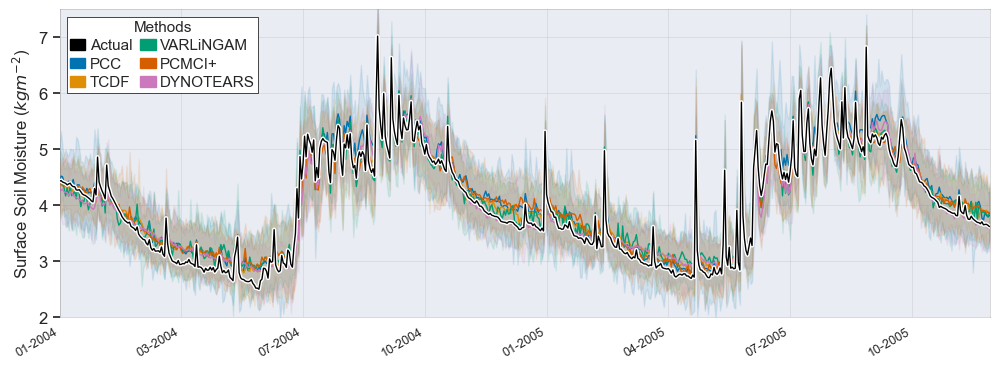

In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.family": "sans-serif",})
# Create custom layout
fig, ax = plt.subplots(figsize=(12, 4), dpi=100)
ax.set_facecolor('#e9ecf2')
ax.plot(x, t1, color='black', lw=1, label='Observed',
             path_effects=[patheffects.withStroke(linewidth=3, foreground="white")],
               zorder=10)
for method_, mean_, std_, min_, max_, color_ in zip(plot_dict['method'], plot_dict['mean'], plot_dict['std'], plot_dict['min'], plot_dict['max'], plot_dict['color']):
    ax.plot(x, mean_, color=color_, lw=1, label=method_, alpha=1,
                # path_effects=[patheffects.withStroke(linewidth=2, foreground="white")],
                zorder=1 )
    # ax.fill_between(x, mean_ - std_, mean_ + std_,
                        # color=color_, alpha=0.1, label=f'{method_} ±1 Std Dev')
    ax.fill_between(x, min_, max_,
                    color=color_, alpha=0.1, label=f'{method_} min-max')
ax.grid(True, linestyle="-", linewidth=0.5, color='grey', alpha=0.2, zorder=0)
ax.set_ylabel(r'Surface Soil Moisture ($kg m^{-2}$)', fontsize=12)
# ax.set_ylabel(r'Surface Storm Runoff ($kg/m^2s^1$)', fontsize=12)
ax.tick_params(axis='y', labelsize=11)
# ax.set_title(f'Prediction of {target_} under drought period', fontsize=12, pad=5)
ax.set_xlim(0, len(time_idx) - 1)
method_names = ['PCC', 'TCDF', 'VARLiNGAM', 'PCMCI+', 'DYNOTEARS']
legend_patches = [mpatches.Patch(color=color_pallete_[i], label=method_names[i]) for i in range(len(method_names))]
legend_patches.insert(0, mpatches.Patch(color="black", label="Actual"))
legend = ax.legend(
    handles=legend_patches,
    title='Methods',
    fontsize=11,              # Smaller text
    title_fontsize=11,        # Smaller title
    frameon=True,
    handleheight=0.7,        # Shorter handles
    handlelength=1.0,        # Shorter legend lines
    handletextpad=0.3,       # Less gap between handle and text
    borderpad=0.2,           # Tighter border padding
    labelspacing=0.3,        # Less vertical spacing
    columnspacing=0.5,       # Tighter columns
    ncol=2,
    loc='upper left',
    bbox_to_anchor=(0, 1),
    fancybox=False,
    shadow=False,
    framealpha=1,
    edgecolor='black',
    facecolor='white',
)

ax.set_ylim(2, 7.5)
ax.set_yticks(np.arange(2, 7.5, step=1))
ax.tick_params(labelsize=12, length=5, axis='y', which='major', direction='out', left=True)

legend.get_frame().set_linewidth(0.5)
xticks = np.arange(0, len(time_idx), 80)
ax.set_xticks(xticks)
ax.set_xticklabels(time_idx[xticks].strftime('%m-%Y'), rotation=30, ha='right', fontsize=9)
ax.tick_params(axis='x', pad=-0.2)
for label in ax.get_xticklabels():
    label.set_verticalalignment('top')
for spine in ax.spines.values():
    spine.set_edgecolor('grey')
    spine.set_linewidth(0.7)
    spine.set_alpha(0.3)
# ax.spines['left'].set_edgecolor('black')
# ax.spines['left'].set_linewidth(1)
# ax.spines['left'].set_alpha(1)
# ax.ticklabel_format(axis='y', style='sci', useMathText=True, useOffset=False, scilimits=(0, 1))
if save_plot:
    fig.savefig(f'./backup_results_figs/production/{target_}_{dir_}_ts.svg', bbox_inches='tight', dpi=400, pad_inches=0.01)
plt.show()

#### --- Performance metrics boxplot ---

In [ ]:
fig, ax_perf = plt.subplots(figsize=(4, 5), dpi=100)
ax_perf.set_position([0.2, 0.15, 0.75, 0.75])
sns.boxplot(
    data=plot_df_perf,
    x="Metric",
    y="Score",
    hue="method",
    flierprops={'marker': 'o', 'markersize': 0.7}, linewidth=1, fill=False,
    palette=color_pallete_,
    width=1, ax=ax_perf, legend=False, whis=[5, 95], gap=0.1
)

ax_perf.set_ylim(0.5, 1.0)
ax_perf.set_yticks(np.arange(0.5, 1.01, step=0.1))

# Assign a FixedLocator (so Matplotlib knows ticks won't change)
tick_positions = ax_perf.get_xticks()
ax_perf.xaxis.set_major_locator(mticker.FixedLocator(tick_positions))
ax_perf.set_xticklabels(['R2', 'NSE', 'NSE-mod', 'KGE'], fontsize=12, fontweight='normal')
ax_perf.set_xticklabels([r'$\mathrm{R^2}$', r'$\mathrm{NSE}$', r'$\mathrm{NSE_{mod}}$', r'$\mathrm{KGE}$'], fontsize=12, fontweight='normal')
ax_perf.tick_params(axis='x', which='major', rotation=30, pad=-3)
ax_perf.tick_params(labelsize=12, length=5, axis='y', which='major', direction='out', left=True)

ax_perf.grid(True, linestyle="-", linewidth=0.7, color='grey', alpha=0.3, zorder=-1, axis='y')


ax_perf.set_xlabel(None)
ax_perf.set_ylabel(None)
for i in range(4):
    if i % 2 != 0:
        ax_perf.axvspan(i - 0.5, i + 0.5, facecolor="lightgrey", alpha=0.2, zorder=0)
        ax_perf.axvspan(i - 0.5, i + 0.5, facecolor="lightgrey", alpha=0.2, zorder=0)
for spine in ax_perf.spines.values():
    spine.set_edgecolor('grey')
    spine.set_linewidth(0.7)
    spine.set_alpha(0.3)
# ax_perf.spines['left'].set_edgecolor('grey')
# ax_perf.spines['left'].set_linewidth(1)
# ax_perf.spines['left'].set_alpha(1)
# ax_perf.set_title('Performance Metrics \n (more is better)', fontsize=12, pad=5, loc='center', y=-0.25)
if save_plot:
    fig.savefig(f'./backup_results_figs/production/{target_}_{dir_}_perf.svg', bbox_inches='tight', dpi=400, pad_inches=0.01)
plt.show()

#### --- Error metrics boxplot ---

In [ ]:
fig, ax_error = plt.subplots(figsize=(2, 5), dpi=100)
ax_error.set_position([0.2, 0.15, 0.75, 0.75])
sns.boxplot(
    data=plot_df_error,
    x="Metric",
    y="Error",
    hue="method",
    flierprops={'marker': 'o', 'markersize': 0.7}, linewidth=1, fill=False,
    palette=color_pallete_,
    width=1, ax=ax_error, legend=False, whis=[5, 95], gap=0.1
)

# Assign a FixedLocator (so Matplotlib knows ticks won't change)
tick_positions = ax_error.get_xticks()
ax_error.xaxis.set_major_locator(mticker.FixedLocator(tick_positions))
ax_error.set_xticklabels(['RMSE', 'MAE'], fontsize=12, fontweight='normal')
ax_error.set_xticklabels([r'$\mathrm{RMSE}$', r'$\mathrm{MAE}$'], fontsize=12, fontweight='normal')
ax_error.tick_params(axis='x', which='major', rotation=30, pad=-3)
ax_error.tick_params(labelsize=12, length=5, axis='y', which='major', direction='out', left=True)

ax_error.grid(True, linestyle="-", linewidth=0.7, color='grey', alpha=0.3, zorder=-1, axis='y')

ax_error.set_ylim(0.4, 0.80)
ax_error.set_yticks(np.arange(0.4, 0.81, step=0.1))

ax_error.set_xlabel(None)
ax_error.set_ylabel(None)
for i in range(3):
    if i % 2 != 0:
        ax_error.axvspan(i - 0.5, i + 0.5, facecolor="lightgrey", alpha=0.2, zorder=0)
        ax_error.axvspan(i - 0.5, i + 0.5, facecolor="lightgrey", alpha=0.2, zorder=0)
for spine in ax_error.spines.values():
    spine.set_edgecolor('grey')
    spine.set_linewidth(0.7)
    spine.set_alpha(0.3)
# ax_error.spines['left'].set_edgecolor('black')
# ax_error.spines['left'].set_linewidth(1)
# ax_error.spines['left'].set_alpha(1)
# ax_error.set_title('Error Metrics \n (less is better)', fontsize=12, pad=5, loc='center', y=-0.25)
if save_plot:
    fig.savefig(f'./backup_results_figs/production/{target_}_{dir_}_error.svg', bbox_inches='tight', dpi=400, pad_inches=0.01)
plt.show()

#### --- Difference ---

In [ ]:
# Melt the dataframe for selected metrics
plot_df_perf_diff = diff_df.melt(
    id_vars='method',
    value_vars=['r2_score', 'nse', 'nse_mod', 'kge'],
    var_name='Metric',
    value_name='Score'
)
# Melt the dataframe for selected metrics
plot_df_error_diff = diff_df.melt(
    id_vars='method',
    value_vars=['rmse', 'mae'],
    var_name='Metric',
    value_name='Error'
)

In [ ]:
fig, ax_perf = plt.subplots(figsize=(4, 5), dpi=100)
ax_perf.set_position([0.2, 0.15, 0.75, 0.75])
sns.boxplot(
    data=plot_df_perf_diff,
    x="Metric",
    y="Score",
    hue="method",
    flierprops={'marker': 'o', 'markersize': 0.7}, linewidth=0.7, fill=True,
    palette=color_pallete_,
    width=1, ax=ax_perf, legend=False, whis=[5, 95], gap=0.1
)

ax_perf.set_ylim(-0.4, 0.1)
ax_perf.set_yticks(np.arange(-0.4, 0.11, step=0.1))

# Assign a FixedLocator (so Matplotlib knows ticks won't change)
tick_positions = ax_perf.get_xticks()
ax_perf.xaxis.set_major_locator(mticker.FixedLocator(tick_positions))
ax_perf.set_xticklabels([r'$\Delta \mathrm{R^2}$', r'$\Delta \mathrm{NSE}$', r'$\Delta \mathrm{NSE_{mod}}$', r'$\Delta \mathrm{KGE}$'], fontsize=13, fontweight='normal')
ax_perf.tick_params(axis='x', which='major', rotation=30, pad=-3)
ax_perf.tick_params(labelsize=12, length=5, axis='y', which='major', direction='out', left=True)
ax_perf.axhline(0, color='darkred', linestyle='-', linewidth=0.7, zorder=1)

ax_perf.grid(True, linestyle="-", linewidth=0.7, color='grey', alpha=0.3, zorder=-1, axis='y')

ax_perf.set_xlabel(None)
ax_perf.set_ylabel(None)
for i in range(4):
    if i % 2 != 0:
        ax_perf.axvspan(i - 0.5, i + 0.5, facecolor="lightgrey", alpha=0.2, zorder=0)
        ax_perf.axvspan(i - 0.5, i + 0.5, facecolor="lightgrey", alpha=0.2, zorder=0)
for spine in ax_perf.spines.values():
    spine.set_edgecolor('grey')
    spine.set_linewidth(0.7)
    spine.set_alpha(0.3)
# ax_perf.spines['left'].set_edgecolor('black')
# ax_perf.spines['left'].set_linewidth(1)
# ax_perf.spines['left'].set_alpha(1)
# ax_perf.set_title('Performance Metrics \n (more is better)', fontsize=12, pad=5, loc='center', y=-0.25)
if save_plot:
    fig.savefig(f'./backup_results_figs/production/{target_}_{dir_}_perf_diff.svg', bbox_inches='tight', dpi=400, pad_inches=0.01)
plt.show()

In [ ]:
fig, ax_error = plt.subplots(figsize=(2, 5), dpi=100)
ax_error.set_position([0.2, 0.15, 0.75, 0.75])
sns.boxplot(
    data=plot_df_error_diff,
    x="Metric",
    y="Error",
    hue="method",
    flierprops={'marker': 'o', 'markersize': 0.7}, linewidth=0.7, fill=True,
    palette=color_pallete_,
    width=1, ax=ax_error, legend=False, whis=[5, 95],  gap=0.1
)

# Assign a FixedLocator (so Matplotlib knows ticks won't change)
tick_positions = ax_error.get_xticks()
ax_error.xaxis.set_major_locator(mticker.FixedLocator(tick_positions))
# ax_error.set_xticklabels(['RMSE', 'MAE'], fontsize=12, fontweight='normal')
ax_error.set_xticklabels([r'$\Delta \mathrm{RMSE}$', r'$\Delta \mathrm{MAE}$'], fontsize=12, fontweight='normal')
ax_error.tick_params(axis='x', which='major', rotation=30, pad=-3)
ax_error.tick_params(labelsize=12, length=5, axis='y', which='major', direction='out', left=True)
ax_error.axhline(0, color='darkred', linestyle='-', linewidth=0.7, zorder=1)

ax_error.grid(True, linestyle="-", linewidth=0.7, color='grey', alpha=0.3, zorder=-1, axis='y')
ax_error.set_ylim(-0.30, 0.1)
ax_error.set_yticks(np.arange(-0.30, 0.11, step=0.1))

ax_error.set_xlabel(None)
ax_error.set_ylabel(None)
for i in range(3):
    if i % 2 != 0:
        ax_error.axvspan(i - 0.5, i + 0.5, facecolor="lightgrey", alpha=0.2, zorder=0)
        ax_error.axvspan(i - 0.5, i + 0.5, facecolor="lightgrey", alpha=0.2, zorder=0)
for spine in ax_error.spines.values():
    spine.set_edgecolor('grey')
    spine.set_linewidth(0.7)
    spine.set_alpha(0.3)
# ax_error.spines['left'].set_edgecolor('black')
# ax_error.spines['left'].set_linewidth(1)
# ax_error.spines['left'].set_alpha(1)
# ax_error.set_title('Error Metrics \n (less is better)', fontsize=12, pad=5, loc='center', y=-0.25)
if save_plot:
    fig.savefig(f'./backup_results_figs/production/{target_}_{dir_}_error_diff.svg', bbox_inches='tight', dpi=400, pad_inches=0.01)
plt.show()